# REINFORCE with Baseline on GridWorld

*See `docs/policy_gradient.md` for full derivations.*

Direct transcription of §§2–6 of `docs/policy_gradient.md` into runnable code.  Each step is labelled with the equation it implements.

In [ ]:
import sys, os
from pathlib import Path
_p = Path.cwd()
while _p != _p.parent and not (_p / 'utils' / 'toy_mdp.py').exists():
    _p = _p.parent
REPO = str(_p)
sys.path.insert(0, REPO)
from utils.env      import ENV
from utils.toy_mdp  import GridWorldEnv, TabularPolicy, TabularValue, reinforce
from utils.train    import plot_history

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ENV.summary()

Device:    mps
Root:      ~/rl-alignment-repo
Repo:      ~/rl-alignment-repo
Models:    ~/models/transformers
Data:      ~/rl-alignment-repo/data
HF cache:  ~/models/hub


## 1. The MDP

5×5 GridWorld. Agent starts at (0,0), goal at (4,4).  
Actions: 0=up, 1=down, 2=left, 3=right.  
Reward: +1 at goal, −0.01 per step. Episode ends at goal or 100 steps.

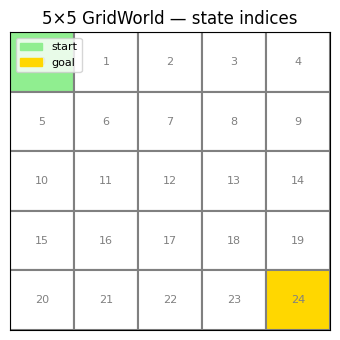

In [10]:
env = GridWorldEnv(H=5, W=5, goal=(4,4), start=(0,0), gamma=0.99)

def draw_grid(env, title=""):
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    for r in range(env.H):
        for c in range(env.W):
            color = ("gold"       if (r,c)==env.goal
                     else "lightgreen" if (r,c)==env.start
                     else "white")
            ax.add_patch(plt.Rectangle([c, env.H-1-r], 1, 1,
                                        facecolor=color, edgecolor="gray", lw=1.5))
            ax.text(c+0.5, env.H-0.5-r, f"{env._flat(r,c)}",
                    ha="center", va="center", fontsize=8, color="gray")
    ax.set_xlim(0, env.W); ax.set_ylim(0, env.H)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    ax.legend(handles=[mpatches.Patch(color="lightgreen", label="start"),
                        mpatches.Patch(color="gold",       label="goal")],
              loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()

draw_grid(env, "5×5 GridWorld — state indices")

## 2. The Score Function (docs/policy_gradient.md §3)

For our softmax tabular policy $\pi_\theta(a|s) = \text{softmax}(\theta_{s,:})_a$, the softmax maps the logit row $\theta_{s,:}$ to a probability distribution over actions:

$$\pi_\theta(a|s) = \text{softmax}(\theta_{s,:})_a = \frac{e^{\theta_{s,a}}}{\sum_{a'} e^{\theta_{s,a'}}}$$

The denominator sums over all actions $a'$ at state $s$, so $\sum_a \pi_\theta(a|s) = 1$. The score is then:

$$\nabla_\theta \log \pi_\theta(a|s) \bigg|_{\theta_{s,a'}} = \mathbf{1}[a'=a] - \pi_\theta(a'|s)$$

That is: $+1$ on the taken action, $-\pi(a'|s)$ on all others — exactly the gradient
of log-softmax. PyTorch computes this automatically via `log_prob.backward()`.  We verify it manually below.

In [11]:
torch.manual_seed(0)
policy = TabularPolicy(n_states=env.n_states, n_actions=env.n_actions)

s, a = 0, 0   # state 0, action 'up'
dist     = policy(s)
log_prob = dist.log_prob(torch.tensor(a))
log_prob.backward()

score_autograd = policy.logits.grad[s].clone()
probs          = torch.softmax(policy.logits[s].detach(), dim=-1)
score_manual   = torch.eye(env.n_actions)[a] - probs  # 1[a'=a] - pi(a'|s)

print(f"State {s}, action {a} (up)")
print(f"Policy probs:          {probs.numpy().round(4)}")
print(f"Score (autograd):      {score_autograd.numpy().round(4)}")
print(f"Score (manual formula):{score_manual.numpy().round(4)}")
print(f"Max diff: {(score_autograd - score_manual).abs().max().item():.2e}")

State 0, action 0 (up)
Policy probs:          [0.25 0.25 0.25 0.25]
Score (autograd):      [ 0.75 -0.25 -0.25 -0.25]
Score (manual formula):[ 0.75 -0.25 -0.25 -0.25]
Max diff: 0.00e+00


## 3. REINFORCE with Baseline (docs/policy_gradient.md §§5–6)

The update at each timestep $t$:

$$\theta \leftarrow \theta + \alpha \cdot \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot \hat{A}_t$$

where $\hat{A}_t = G_t - V(s_t)$ is the advantage estimate and
$G_t = \sum_{t' \geq t} \gamma^{t'-t} r_{t'}$ is the discounted return.

The value baseline is updated separately by MSE:
$V(s_t) \leftarrow V(s_t) + \alpha_V \cdot (G_t - V(s_t))$.

In [12]:
torch.manual_seed(0)
env    = GridWorldEnv(H=5, W=5, goal=(4,4), start=(0,0), gamma=0.99, max_steps=100)
policy = TabularPolicy(n_states=env.n_states, n_actions=env.n_actions)
value  = TabularValue(n_states=env.n_states)

history = reinforce(env, policy, value,
                    n_episodes=4000,
                    lr_policy=5e-2,
                    lr_value=5e-2,
                    gamma=0.99)

print(f"Mean return (last 200 eps): {np.mean(history['returns'][-200:]):.4f}")

Mean return (last 200 eps): 0.8639


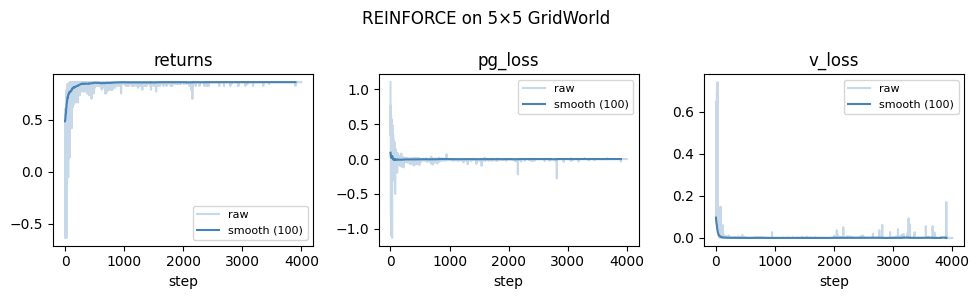

In [13]:
plot_history(history,
             keys=["returns", "pg_loss", "v_loss"],
             title="REINFORCE on 5×5 GridWorld",
             smooth_window=100)

## 4. Learned Policy and Value Function

Arrow = greedy action $\arg\max_a \pi_\theta(a|s)$.  
Gray dot = no clear preference (top two action probabilities within `tie_eps`),
e.g. an untrained or indifferent state — drawn instead of an arrow so an
`argmax` tie can't masquerade as a confident "up".  
Color = $V(s)$ — darker blue means higher estimated value.  
The value gradient should point toward the goal.

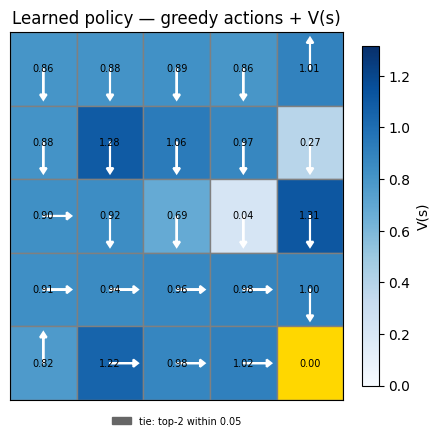

In [14]:
ARROW_DXY = {0:(0,.35), 1:(0,-.35), 2:(-.35,0), 3:(.35,0)}  # up dn left right

def draw_policy(env: GridWorldEnv, policy: TabularPolicy, value: TabularValue,
                title: str = "Learned policy", tie_eps: float = 0.05) -> None:
    pi = torch.softmax(policy.logits, dim=-1).detach().numpy()
    V  = value.V.detach().numpy()
    vmin, vmax = V.min(), V.max()

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    for r in range(env.H):
        for c in range(env.W):
            s     = env._flat(r, c)
            norm  = (V[s]-vmin)/(vmax-vmin+1e-8)
            color = "gold" if (r,c)==env.goal else plt.cm.Blues(0.15 + 0.7*norm)
            ax.add_patch(plt.Rectangle([c, env.H-1-r], 1, 1,
                                        facecolor=color, edgecolor="gray", lw=1))
            ax.text(c+0.5, env.H-0.5-r, f"{V[s]:.2f}",
                    ha="center", va="center", fontsize=7, color="black")
            if (r,c) == env.goal:
                continue
            # Gray dot when the top two actions are within tie_eps of each other
            # (no clear preference) so a near-tie can't masquerade as a confident
            # "up": argmax breaks ties toward action 0, which is exactly what an
            # untrained / indifferent state would otherwise look like.
            p:    np.ndarray = pi[s]
            top2: np.ndarray = np.sort(p)[::-1][:2]
            if (top2[0] - top2[1]) < tie_eps:
                ax.plot(c+0.5, env.H-0.5-r, marker="o", ms=5, color="0.4")
            else:
                dx, dy = ARROW_DXY[int(np.argmax(p))]
                ax.arrow(c+0.5, env.H-0.5-r, dx, dy,
                         head_width=0.10, head_length=0.07,
                         fc="white", ec="white", lw=1.5)

    ax.set_xlim(0,env.W); ax.set_ylim(0,env.H)
    ax.set_xticks([]); ax.set_yticks([])
    sm = plt.cm.ScalarMappable(cmap="Blues",
                                norm=plt.Normalize(vmin=vmin, vmax=vmax))
    plt.colorbar(sm, ax=ax, label="V(s)", fraction=0.046)
    ax.legend(handles=[mpatches.Patch(color="0.4",
                                      label=f"tie: top-2 within {tie_eps:g}")],
              loc="upper center", bbox_to_anchor=(0.5, -0.02),
              fontsize=7, frameon=False)
    ax.set_title(title); plt.tight_layout(); plt.show()

draw_policy(env, policy, value, "Learned policy — greedy actions + V(s)")

## 5. Advantage Table $A(s,a)$ (docs/policy_gradient.md §6)

$A(s,a) = Q(s,a) - V(s)$ — how much better is action $a$ than the average action
under the current policy?

We estimate $Q(s,a)$ by Monte Carlo: fix action $a$ at state $s$, then follow $\pi_\theta$.
Positive advantage → policy gradient pushes $\pi_\theta(a|s)$ up.  
Negative advantage → pushes it down.

In [15]:
def advantage_table(env, policy, value, gamma=0.99, n_rollouts=300):
    pi = torch.softmax(policy.logits, dim=-1).detach()
    V  = value.V.detach().numpy()
    ACTION_NAMES = ["↑", "↓", "←", "→"]

    header = f"{'s':>4} {'(r,c)':<7}" + "".join(f"{n:>8}" for n in ACTION_NAMES) + f"{'V(s)':>8}"
    print(header); print("-" * len(header))

    for s in range(env.n_states):
        r, c = env._rc(s)
        if (r,c) == env.goal: continue
        row = []
        for a in range(env.n_actions):
            returns = []
            for _ in range(n_rollouts):
                env2 = GridWorldEnv(H=env.H, W=env.W, goal=env.goal,
                                     start=(r,c), gamma=gamma,
                                     max_steps=env.max_steps)
                s2, rew, done = env2.step(a)
                G, disc = rew, gamma
                while not done:
                    a2       = torch.multinomial(pi[s2], 1).item()
                    s2, rew, done = env2.step(a2)
                    G += disc * rew; disc *= gamma
                returns.append(G)
            row.append(np.mean(returns) - V[s])
        print(f"{s:>4} ({r},{c})    " + "".join(f"{v:>8.3f}" for v in row) + f"{V[s]:>8.3f}")

advantage_table(env, policy, value)

   s (r,c)         ↑       ↓       ←       →    V(s)
----------------------------------------------------
   0 (0,0)      -0.019   0.000  -0.019  -0.015   0.864
   1 (0,1)      -0.031  -0.001  -0.037  -0.023   0.882
   2 (0,2)      -0.032  -0.006  -0.048  -0.034   0.894
   3 (0,3)       0.001   0.046   0.003  -0.030   0.857
   4 (0,4)      -0.169  -0.105  -0.142  -0.174   1.009
   5 (1,0)      -0.038  -0.000  -0.019  -0.001   0.883
   6 (1,1)      -0.435  -0.382  -0.420  -0.397   1.284
   7 (1,2)      -0.200  -0.135  -0.174  -0.149   1.056
   8 (1,3)      -0.110  -0.036  -0.076  -0.069   0.968
   9 (1,4)       0.558   0.686   0.630   0.628   0.275
  10 (2,0)      -0.038  -0.001  -0.019  -0.000   0.902
  11 (2,1)      -0.039  -0.000  -0.038  -0.001   0.921
  12 (2,2)       0.198   0.247   0.209   0.238   0.693
  13 (2,3)       0.861   0.920   0.879   0.920   0.040
  14 (2,4)      -0.409  -0.334  -0.385  -0.355   1.314
  15 (3,0)      -0.027  -0.016  -0.009   0.012   0.909
  16 (3,1)    

## 6. Aside: Why Euclidean Gradient Ascent is Suboptimal (docs/policy_gradient.md §7)

The update $\theta \leftarrow \theta + \alpha \nabla_\theta J$ moves in Euclidean
parameter space, but the induced KL change in $\pi_\theta$ depends on the
curvature of the policy manifold — i.e. the Fisher information $F(\theta)$.

We can measure this directly: take two steps of equal Euclidean length from
the same point and compare the resulting KL divergences from the starting policy.

In [16]:
# Two random directions of equal Euclidean norm
torch.manual_seed(1)
theta0 = policy.logits.detach().clone()
d1 = torch.randn_like(theta0); d1 = d1 / d1.norm()
d2 = torch.randn_like(theta0); d2 = d2 / d2.norm()

eps = 0.5
pi0 = torch.softmax(theta0, dim=-1)
pi1 = torch.softmax(theta0 + eps*d1, dim=-1)
pi2 = torch.softmax(theta0 + eps*d2, dim=-1)

def kl(p, q):
    return (p * (p.log() - q.log())).sum().item()

kl1 = sum(kl(pi0[s], pi1[s]) for s in range(env.n_states))
kl2 = sum(kl(pi0[s], pi2[s]) for s in range(env.n_states))

print(f"Both directions have Euclidean norm = {eps:.2f}")
print(f"KL(pi0 || pi0+eps*d1) = {kl1:.4f}")
print(f"KL(pi0 || pi0+eps*d2) = {kl2:.4f}")
print(f"Ratio: {max(kl1,kl2)/min(kl1,kl2):.2f}x difference in distribution space")
print()
print("Natural gradient would equalise these by pre-multiplying by F^{-1}.")

Both directions have Euclidean norm = 0.50
KL(pi0 || pi0+eps*d1) = 0.0040
KL(pi0 || pi0+eps*d2) = 0.0092
Ratio: 2.31x difference in distribution space

Natural gradient would equalise these by pre-multiplying by F^{-1}.
